# 03 - Regularization tuning

Notebook pour tester BatchNorm, Dropout, Early Stopping et regularisation L2.

In [3]:
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

ROOT_DIR = Path.cwd().parents[0]
IMAGE_SIZE = (256, 256)


def build_regularized_cnn(input_shape=(256, 256, 3), l2_weight=1e-4, dropout_rate=0.5):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255)(inputs)

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding='same', kernel_regularizer=regularizers.l2(l2_weight))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(l2_weight))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = keras.Model(inputs, outputs, name='regularized_cnn')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='mae', metrics=['mae', 'mse'])
    return model


regularized_model = build_regularized_cnn()
regularized_model.summary()

regularization_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
]

print('CNN regularise pret a comparer avec la baseline.')

Model: "regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,297 (434.75 KB)

 Trainable params: 110,593 (432.00 KB)

 Non-trainable params: 704 (2.75 KB)

CNN regularise pret a comparer avec la baseline.


## Chargement des donnees

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_DIR = ROOT_DIR / 'data'
BATCH_SIZE = 16
SEED = 42

csv_path = DATA_DIR / 'boneage-training-dataset.csv'
df = pd.read_csv(csv_path)

train_img_dir = DATA_DIR / 'boneage-training-dataset' / 'boneage-training-dataset'
df['filepath'] = df['id'].apply(lambda x: str(train_img_dir / f'{x}.png'))

train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED)
print(f'Train: {len(train_df)}, Val: {len(val_df)}')

Train: 10088, Val: 2523


In [5]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

train_paths = train_df['filepath'].tolist()
train_labels = train_df['boneage'].astype('float32').tolist()
val_paths = val_df['filepath'].tolist()
val_labels = val_df['boneage'].astype('float32').tolist()

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f'Train: {train_ds}, Val: {val_ds}')

Train: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>, Val: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


## Entrainement avec regularisation

In [6]:
# entrainement
history = regularized_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=regularization_callbacks,
    verbose=1
)

Epoch 1/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 833s 1s/step - loss: 92.4443 - mae: 92.4151 - mse: 10735.6582 - val_loss: 47.1306 - val_mae: 47.0965 - val_mse: 3590.4858 - learning_rate: 0.0010
Epoch 2/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 905s 1s/step - loss: 36.8106 - mae: 36.7690 - mse: 2086.0984 - val_loss: 641.5740 - val_mae: 641.5248 - val_mse: 414985.6562 - learning_rate: 0.0010
Epoch 3/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 774s 1s/step - loss: 32.5220 - mae: 32.4673 - mse: 1660.5759 - val_loss: 3860.9275 - val_mae: 3860.8672 - val_mse: 14912093.0000 - learning_rate: 0.0010
Epoch 4/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 880s 1s/step - loss: 30.5825 - mae: 30.5180 - mse: 1481.6464 - val_loss: 8312.4658 - val_mae: 8312.3945 - val_mse: 69108520.0000 - learning_rate: 0.0010
Epoch 5/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 766s 1s/step - loss: 28.7876 - mae: 28.7181 - mse: 1328.3572 - val_loss: 217.7010 - val_mae: 217.6306 - val_mse: 49287.6797 - learning_rate: 5.0000e-04
Epoch 6/15
631/631 ━━━━━━━━━━━━━━━━━━━━ 669s 1s

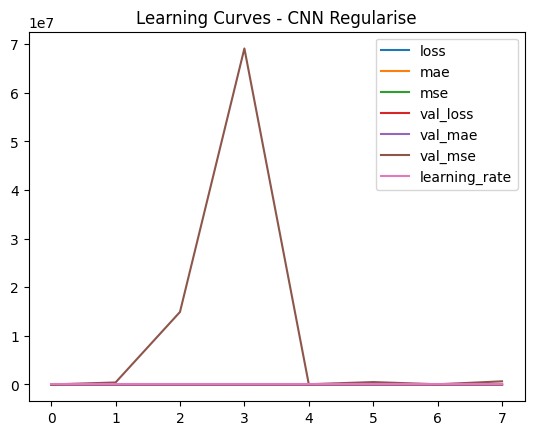

MAE sur validation: 47.10 mois


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

pd.DataFrame(history.history).plot()
plt.title('Learning Curves - CNN Regularise')
plt.show()

y_pred = regularized_model.predict(val_ds, verbose=0).flatten()
y_true = np.array(val_labels)
mae = mean_absolute_error(y_true, y_pred)
print(f'MAE sur validation: {mae:.2f} mois')